## Methodology

The objective is to predict a continuous grammar score from spoken audio samples. Since the input data consists of variable-length speech recordings, the audio signals are first converteed into numerical acoustic features that can be used by regression models.

The methodology consists of the following stages:

1. **Audio preprocessing:** Each WAV audio file is loadeed as a mono signal at a sampling rate of 16kHz. The mean of the audio signal is removed to reduce the effect of DC offset.
   
2. **Feature Extraction:** Mel-Frequency Cepstral Coefficients(MFCCs) are extracted from each audio recording. MFCCs capture important spectral characteristics of speech and are commonly used for speech-related machine learning tasks.

3. **Feature Aggregation:** Since audio recordings have different numbers of time frames, the 13 MFCC coefficients are summarized using their mean and standard deviation across time. This produces a fixed-length feature vector of 26 features for every audio sample.

4. **Model Development:** Multiple regression algorithms are evaluated, including Linear Regression, Ridge Regression, Random Forest, Extra Trees, Gradient Boosting, XGBoost, HistGradientBoosting, K-Nearest Neighbors, and Support Vector Regression(SVR).

5. **Model Evaluation:** All models are evaluated using the same 6-fold cross-validation splits. Root Mean Squared Error(RMSE) and Pearson Correlation are used as the primary evaluation metrics. Lower RMSE indicates lower prediction error, while higher Pearson Correlation indicates a stronger relationship between predicted and actual grammar scores.

6. **Model Selection and Tuning:** The model with the strongest cross-validation performance is selected for further tuning. The final model uses an RBF-kernel Support Vector Regression with standardized features.

7. **Final Prediction:** The selected model is retained using the ocmplete training dataset and used to generate continuous grammar-score predictions between 0 and 5 for the test audio samples.


## Pipeline Architecture

**Audio Input -> Audio PReprocessing -> MFCC Feature Extraction -> Statistical Feature Aggregation ->Feature Standardization -> SVR Regression -> Continuous Grammar Score (0-5)**

In [1]:
import os
print(os.getcwd())
print(os.listdir("Dataset_Final"))

/Users/sowmyabalagala/Desktop/grammar_scoring_engine
['.DS_Store', 'test', 'test.csv', 'train', 'train.csv', 'sample_submission.csv']


## Dataset Loading

In [2]:
import pandas as pd
train = pd.read_csv("Dataset_Final/train.csv")
test = pd.read_csv("Dataset_Final/test.csv")
sample_submission = pd.read_csv("Dataset_Final/sample_submission.csv")
print("TRAIN:")
display(train.head())
print("\nTest:")
print(test.head())

TRAIN:


,filename,label
0,audio_192.wav,3.0
1,audio_436.wav,3.0
2,audio_447.wav,3.5
3,audio_126.wav,2.0
4,audio_61.wav,2.0



Test:
        filename  label
0  audio_128.wav     -1
1  audio_156.wav     -1
2   audio_19.wav     -1
3  audio_108.wav     -1
4  audio_206.wav     -1


In [3]:
print("Training samples:",len(train))
print("Test samples:",len(test))
print(train["label"].describe())
print(sorted(train["label"].unique()))

Training samples: 769
Test samples: 216
count    769.000000
mean       3.313394
std        1.239000
min        0.000000
25%        2.500000
50%        3.000000
75%        4.000000
max        5.000000
Name: label, dtype: float64
[np.float64(0.0), np.float64(1.0), np.float64(1.5), np.float64(2.0), np.float64(2.5), np.float64(3.0), np.float64(3.5), np.float64(4.0), np.float64(4.5), np.float64(5.0)]


In [4]:
audio_file = train.iloc[0]["filename"]
audio_path = os.path.join("Dataset_Final","train",audio_file)
print(audio_file)
print(audio_path)
print(os.path.exists(audio_path))

audio_192.wav
Dataset_Final/train/audio_192.wav
True


## Exploratory Data Analysis

In [5]:
import librosa
audio,sr = librosa.load(audio_path,sr=None)
print(sr)
print(len(audio))
print("Duration:",len(audio)/sr)

16000
968134
Duration: 60.508375


In [6]:
print("Audio shape:", audio.shape)
print("Sampling rate:",sr)
print("Max amplitude:",audio.max())
print("Min amplitude:",audio.min())

Audio shape: (968134,)
Sampling rate: 16000
Max amplitude: 0.38607788
Min amplitude: -0.4777832


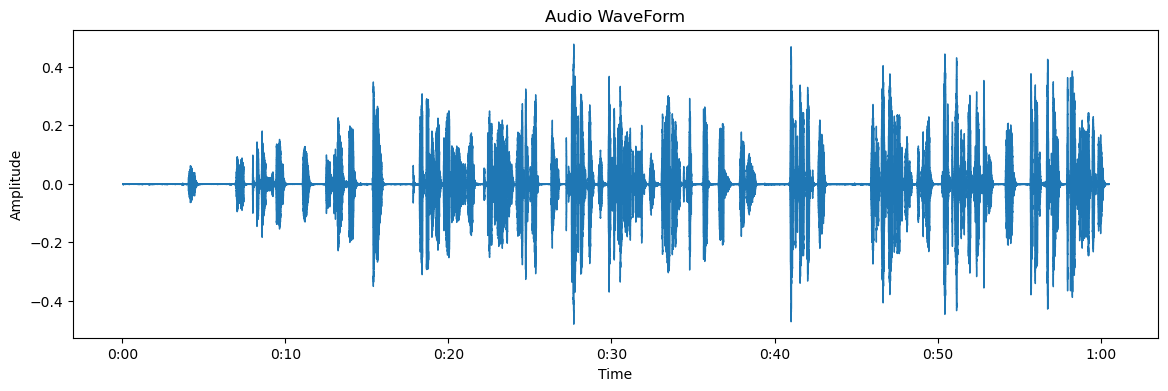

In [7]:
import matplotlib.pyplot as plt
import librosa.display
plt.figure(figsize=(14,4))
librosa.display.waveshow(audio,sr=sr)
plt.title("Audio WaveForm")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.show()


In [8]:
import numpy as np

print("Mean amplitude:", np.mean(audio))
print("Standard deviation:", np.std(audio))
print("RMS energy:", np.sqrt(np.mean(audio**2)))
print("Maximum absolute amplitude:", np.max(np.abs(audio)))

Mean amplitude: -1.0599986e-05
Standard deviation: 0.049853407
RMS energy: 0.049853407
Maximum absolute amplitude: 0.4777832


In [9]:
sampling_rates = []
durations = []
peak_amplitudes = []
for filename in train["filename"]:
    path = os.path.join("Dataset_Final","train",filename)
    audio,sr = librosa.load(path,sr=None)
    sampling_rates.append(sr)
    durations.append(len(audio)/sr)
    peak_amplitudes.append(np.max(np.abs(audio)))
print(sampling_rates)
print("Minimum:",min(durations))
print("Maximum:",max(durations))
print("Mean:",np.mean(durations))
print("Minimum:",min(peak_amplitudes))
print("Maximum:",max(peak_amplitudes))
print("Mean:",np.mean(peak_amplitudes))

[16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000

## Audio Preprocessing

In [10]:
def preprocess_audio(audio_path):
    audio,sr = librosa.load(audio_path,sr=16000,mono=True)
    audio = audio-np.mean(audio)
    return audio,sr

In [11]:
audio_path = os.path.join("Dataset_Final","train",train.iloc[0]["filename"])
processed_audio,sr_processed = preprocess_audio(audio_path)
print("Sampling rate:", sr_processed)
print("Number of samples:", len(processed_audio))
print("Mean amplitude:", np.mean(processed_audio))
print("Minimum amplitude:", np.min(processed_audio))
print("Maximum amplitude:", np.max(processed_audio))

Sampling rate: 16000
Number of samples: 968134
Mean amplitude: 1.15648865e-10
Minimum amplitude: -0.4777726
Maximum amplitude: 0.3860885


In [12]:
mfcc = librosa.feature.mfcc(y=processed_audio,sr=sr_processed,n_mfcc=13)
print(mfcc.shape)
mfcc_mean = np.mean(mfcc,axis=1)
mfcc_std = np.std(mfcc,axis=1)
print(mfcc_mean.shape)
print(mfcc_mean)
print(mfcc_std.shape)
print(mfcc_std)

(13, 1891)
(13,)
[-403.8349     103.5777     -14.212164    16.67498      7.0499153
   -4.998278     5.8870907   -9.267575    -8.679702    -6.1099925
  -11.945686    -8.224803    -6.2368526]
(13,)
[121.62878    68.03509    37.100758   21.84354    11.19238    14.074414
  10.086682   11.239371    9.175532    7.0058413   8.755505    6.883437
   5.746991 ]


## Feature Extraction

In [13]:
def extract_mfcc_features(audio_path):
    #preprocess audio
    #calculate 13 MFCCs
    #calculate mean and std of each MFCC
    #combine them into one feature vector
    audio,sr = preprocess_audio(audio_path)
    mfcc = librosa.feature.mfcc(y=audio,sr=sr,n_mfcc=13)
    mfcc_mean = np.mean(mfcc,axis=1)
    mfcc_std = np.std(mfcc,axis=1)
    features = np.concatenate([mfcc_mean,mfcc_std])
    return features

In [14]:
features=extract_mfcc_features(audio_path)
print(features.shape)
print(len(features))
print(features)

(26,)
26
[-403.8349     103.5777     -14.212164    16.67498      7.0499153
   -4.998278     5.8870907   -9.267575    -8.679702    -6.1099925
  -11.945686    -8.224803    -6.2368526  121.62878     68.03509
   37.100758    21.84354     11.19238     14.074414    10.086682
   11.239371     9.175532     7.0058413    8.755505     6.883437
    5.746991 ]


In [15]:
feature_lengths = []
failed_files = []
for filename in train["filename"]:
    audio_path = os.path.join("Dataset_Final","train",filename)
    try:
        features = extract_mfcc_features(audio_path)
        feature_lengths.append(len(features))
    except Exception as e:
        failed_files.append((filename,str(e)))
print(len(train))
print(len(feature_lengths))
print(len(failed_files))
print(sorted(set(feature_lengths)))
if failed_files:
    for file,error in failed_files:
        print(file,"->",error)

769
769
0
[26]


## Feature Matrix Construction

In [16]:
X_train = []
for filename in train["filename"]:
    audio_path = os.path.join("Dataset_Final","train",filename)
    features = extract_mfcc_features(audio_path)
    X_train.append(features)
X_train = np.array(X_train)
print(X_train.shape)

(769, 26)


In [17]:
Y_train = train["label"]
print(Y_train.shape)
print(Y_train[:10])

(769,)
0    3.0
1    3.0
2    3.5
3    2.0
4    2.0
5    2.5
6    2.0
7    3.0
8    4.0
9    4.0
Name: label, dtype: float64


In [18]:
print("NaN values:", np.isnan(X_train).sum())
print("Infinite values:", np.isinf(X_train).sum())
print("Feature matrix shape:", X_train.shape)

NaN values: 0
Infinite values: 0
Feature matrix shape: (769, 26)


## Model Evaluation

In [19]:
from sklearn.model_selection import KFold
kf = KFold(n_splits=6,shuffle=True,random_state=42)
print(kf.get_n_splits(X_train))

6


In [20]:
for fold,(train_idx,val_idx) in enumerate(kf.split(X_train),start=1):
    print(f"Fold{fold}: "
          f"Training samples = {len(train_idx)}, "
          f"Validation samples={len(val_idx)}")

Fold1: Training samples = 640, Validation samples=129
Fold2: Training samples = 641, Validation samples=128
Fold3: Training samples = 641, Validation samples=128
Fold4: Training samples = 641, Validation samples=128
Fold5: Training samples = 641, Validation samples=128
Fold6: Training samples = 641, Validation samples=128


In [21]:
print("\nUnique training labels:")
print(sorted(train["label"].unique()))


Unique training labels:
[np.float64(0.0), np.float64(1.0), np.float64(1.5), np.float64(2.0), np.float64(2.5), np.float64(3.0), np.float64(3.5), np.float64(4.0), np.float64(4.5), np.float64(5.0)]


## Model Comparison

In [22]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
print(model)

LinearRegression()


In [23]:
from sklearn.metrics import root_mean_squared_error
from scipy.stats import pearsonr
rmse_scores=[]
pearson_scores = []
for fold,(train_idx,val_idx) in enumerate(kf.split(X_train),start=1):
    X_fold_train = X_train[train_idx]
    X_fold_val = X_train[val_idx]
    y_fold_train = Y_train.iloc[train_idx]
    y_fold_val = Y_train.iloc[val_idx]
    model = LinearRegression()
    model.fit(X_fold_train,y_fold_train)
    y_pred = model.predict(X_fold_val)
    rmse = root_mean_squared_error(y_fold_val,y_pred)
    pearson = pearsonr(y_fold_val,y_pred)[0]
    rmse_scores.append(rmse)
    pearson_scores.append(pearson)
    print(f"Fold {fold}: "
          f"RMSE = {rmse:.5f}, "
          f"Pearson = {pearson:.5f}")
print(np.mean(rmse_scores))
print(np.mean(pearson_scores))

Fold 1: RMSE = 0.78719, Pearson = 0.83094
Fold 2: RMSE = 0.86063, Pearson = 0.74871
Fold 3: RMSE = 0.86486, Pearson = 0.50592
Fold 4: RMSE = 0.94252, Pearson = 0.67887
Fold 5: RMSE = 0.93453, Pearson = 0.68218
Fold 6: RMSE = 0.85353, Pearson = 0.69591
0.8738757498827181
0.6904221264775593


In [24]:
print("Prediction minimum:", y_pred.min())
print("Prediction maximum:", y_pred.max())
print("Prediction standard deviation:", np.std(y_pred))

print("\nFirst 10 predictions:")
print(y_pred[:10])
print("Feature standard deviation:")
print(np.std(X_train, axis=0))

print("\nNumber of unique values in each feature:")
print([len(np.unique(X_train[:, i])) for i in range(X_train.shape[1])])

Prediction minimum: 0.25346094
Prediction maximum: 5.380267
Prediction standard deviation: 0.8219071

First 10 predictions:
[3.7017813 3.6605058 3.540234  3.3511455 3.1002407 3.2639296 3.4175677
 3.5838025 2.9327233 3.2776315]
Feature standard deviation:
[94.482475  29.642323  16.720325  12.494728  11.739663   9.423758
  8.234645   7.6403627  6.708839   5.973429   5.82341    5.225246
  4.7898235 36.33848   16.938244  10.026203   8.050335   6.1604323
  4.8455815  4.3120646  3.593173   3.3060262  2.9904494  2.4806435
  2.4545221  2.2198527]

Number of unique values in each feature:
[769, 769, 769, 769, 769, 769, 769, 769, 769, 769, 769, 769, 768, 769, 769, 769, 769, 769, 769, 769, 769, 769, 769, 769, 769, 769]


In [25]:
file1 = train.iloc[0]["filename"]
file2 = train.iloc[1]["filename"]

path1 = os.path.join("Dataset_Final", "train", file1)
path2 = os.path.join("Dataset_Final", "train", file2)

features1 = extract_mfcc_features(path1)
features2 = extract_mfcc_features(path2)

print("File 1:", file1)
print("File 2:", file2)

print("\nFeatures 1:")
print(features1)

print("\nFeatures 2:")
print(features2)

print("\nAre the feature vectors identical?",
      np.array_equal(features1, features2))

File 1: audio_192.wav
File 2: audio_436.wav

Features 1:
[-403.8349     103.5777     -14.212164    16.67498      7.0499153
   -4.998278     5.8870907   -9.267575    -8.679702    -6.1099925
  -11.945686    -8.224803    -6.2368526  121.62878     68.03509
   37.100758    21.84354     11.19238     14.074414    10.086682
   11.239371     9.175532     7.0058413    8.755505     6.883437
    5.746991 ]

Features 2:
[-2.87111023e+02  7.20876236e+01  5.33474588e+00  2.48543739e+01
 -1.31094055e+01  1.68615893e-01 -1.56320505e+01 -2.08259373e+01
 -6.67116261e+00 -8.47017479e+00 -9.26119900e+00 -9.04073524e+00
  4.75152159e+00  8.16859970e+01  5.60210571e+01  4.61735687e+01
  3.70730743e+01  2.71772079e+01  1.95318661e+01  2.14836617e+01
  1.92375431e+01  1.60023575e+01  1.34481497e+01  1.15543900e+01
  1.32952652e+01  1.35322256e+01]

Are the feature vectors identical? False


In [26]:
print(extract_mfcc_features)
print(preprocess_audio)

<function extract_mfcc_features at 0x14b405a80>
<function preprocess_audio at 0x148616840>


In [27]:
import inspect

print(inspect.getsource(preprocess_audio))
print(inspect.getsource(extract_mfcc_features))

def preprocess_audio(audio_path):
    audio,sr = librosa.load(audio_path,sr=16000,mono=True)
    audio = audio-np.mean(audio)
    return audio,sr

def extract_mfcc_features(audio_path):
    #preprocess audio
    #calculate 13 MFCCs
    #calculate mean and std of each MFCC
    #combine them into one feature vector
    audio,sr = preprocess_audio(audio_path)
    mfcc = librosa.feature.mfcc(y=audio,sr=sr,n_mfcc=13)
    mfcc_mean = np.mean(mfcc,axis=1)
    mfcc_std = np.std(mfcc,axis=1)
    features = np.concatenate([mfcc_mean,mfcc_std])
    return features



In [28]:
from sklearn.linear_model import Ridge
model = Ridge(alpha=1.0)
print(model)

Ridge()


In [29]:
from sklearn.linear_model import Ridge
from sklearn.metrics import root_mean_squared_error
from scipy.stats import pearsonr
ridge_rmse_scores=[]
ridge_pearson_scores = []
for fold,(train_idx,val_idx) in enumerate(kf.split(X_train),start=1):
    X_fold_train = X_train[train_idx]
    X_fold_val = X_train[val_idx]
    y_fold_train = Y_train.iloc[train_idx]
    y_fold_val = Y_train.iloc[val_idx]
    model = Ridge(alpha=1.0)
    model.fit(X_fold_train,y_fold_train)
    y_pred = model.predict(X_fold_val)
    rmse = root_mean_squared_error(y_fold_val,y_pred)
    pearson = pearsonr(y_fold_val,y_pred)[0]
    ridge_rmse_scores.append(rmse)
    ridge_pearson_scores.append(pearson)
    print(f"Fold {fold}: "
          f"RMSE = {rmse:.5f}, "
          f"Pearson = {pearson:.5f}")
print(np.mean(ridge_rmse_scores))
print(np.mean(ridge_pearson_scores))

Fold 1: RMSE = 0.78715, Pearson = 0.83097
Fold 2: RMSE = 0.86062, Pearson = 0.74872
Fold 3: RMSE = 0.86486, Pearson = 0.50592
Fold 4: RMSE = 0.94251, Pearson = 0.67889
Fold 5: RMSE = 0.93451, Pearson = 0.68219
Fold 6: RMSE = 0.85354, Pearson = 0.69590
0.8738632241527523
0.6904292908788806


In [30]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(n_estimators=200,random_state=42)
print(model)

RandomForestRegressor(n_estimators=200, random_state=42)


In [31]:
rf_rmse_scores = []
rf_pearson_scores = []
for fold, (train_idx,val_idx) in enumerate(kf.split(X_train),start=1):
    X_fold_train = X_train[train_idx]
    X_fold_val = X_train[val_idx]
    y_fold_train = Y_train.iloc[train_idx]
    y_fold_val = Y_train.iloc[val_idx]
    model = RandomForestRegressor(n_estimators=200,random_state=42)
    model.fit(X_fold_train,y_fold_train)
    y_pred = model.predict(X_fold_val)
    rmse = root_mean_squared_error(y_fold_val,y_pred)
    pearson = pearsonr(y_fold_val,y_pred)[0]
    rf_rmse_scores.append(rmse)
    rf_pearson_scores.append(pearson)
    print(f"Fold {fold}: "
          f"RMSE = {rmse:.5f}, "
          f"Pearson = {pearson:.5f}")
print("Average RMSE:", np.mean(rf_rmse_scores))
print("Average Pearson:", np.mean(rf_pearson_scores))

Fold 1: RMSE = 0.74847, Pearson = 0.84768
Fold 2: RMSE = 0.77723, Pearson = 0.79512
Fold 3: RMSE = 0.74406, Pearson = 0.64376
Fold 4: RMSE = 0.84044, Pearson = 0.76026
Fold 5: RMSE = 0.83802, Pearson = 0.75008
Fold 6: RMSE = 0.81475, Pearson = 0.72893
Average RMSE: 0.7938304294994997
Average Pearson: 0.7543036247426885


In [32]:
from sklearn.ensemble import ExtraTreesRegressor

et_rmse_scores = []
et_pearson_scores = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train), start=1):

    X_fold_train = X_train[train_idx]
    X_fold_val = X_train[val_idx]

    y_fold_train = Y_train.iloc[train_idx]
    y_fold_val = Y_train.iloc[val_idx]

    model = ExtraTreesRegressor(
        n_estimators=200,
        random_state=42
    )

    model.fit(X_fold_train, y_fold_train)

    y_pred = model.predict(X_fold_val)

    rmse = root_mean_squared_error(y_fold_val, y_pred)
    pearson = pearsonr(y_fold_val, y_pred)[0]

    et_rmse_scores.append(rmse)
    et_pearson_scores.append(pearson)

    print(
        f"Fold {fold}: "
        f"RMSE = {rmse:.5f}, "
        f"Pearson = {pearson:.5f}"
    )

print("\nExtra Trees Results")
print("------------------")
print("Average RMSE:", np.mean(et_rmse_scores))
print("Average Pearson:", np.mean(et_pearson_scores))

Fold 1: RMSE = 0.71145, Pearson = 0.86415
Fold 2: RMSE = 0.76296, Pearson = 0.80147
Fold 3: RMSE = 0.70838, Pearson = 0.68480
Fold 4: RMSE = 0.83143, Pearson = 0.76433
Fold 5: RMSE = 0.81517, Pearson = 0.76561
Fold 6: RMSE = 0.79161, Pearson = 0.74857

Extra Trees Results
------------------
Average RMSE: 0.7701672103382254
Average Pearson: 0.7714870492643814


In [33]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr
import numpy as np


gbr_model = GradientBoostingRegressor(
    n_estimators=200,
    random_state=42
)

gbr_rmse_scores = []
gbr_pearson_scores = []


for fold, (train_idx, val_idx) in enumerate(kf.split(X_train), 1):

    X_tr = X_train[train_idx]
    X_val = X_train[val_idx]

    y_tr = Y_train.iloc[train_idx]
    y_val = Y_train.iloc[val_idx]

    # Train
    gbr_model.fit(X_tr, y_tr)

    # Predict validation set
    y_pred = gbr_model.predict(X_val)

    # Calculate RMSE
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))

    # Calculate Pearson correlation
    pearson = pearsonr(y_val, y_pred)[0]

    gbr_rmse_scores.append(rmse)
    gbr_pearson_scores.append(pearson)

    print(f"Fold {fold}: RMSE = {rmse:.5f}, Pearson = {pearson:.5f}")


print("\nGradient Boosting Results:")
print(f"Average RMSE = {np.mean(gbr_rmse_scores):.5f}")
print(f"Average Pearson = {np.mean(gbr_pearson_scores):.5f}")

Fold 1: RMSE = 0.76722, Pearson = 0.83821
Fold 2: RMSE = 0.78791, Pearson = 0.78881
Fold 3: RMSE = 0.73908, Pearson = 0.65322
Fold 4: RMSE = 0.83610, Pearson = 0.75741
Fold 5: RMSE = 0.85434, Pearson = 0.73750
Fold 6: RMSE = 0.90356, Pearson = 0.65545

Gradient Boosting Results:
Average RMSE = 0.81470
Average Pearson = 0.73843


In [34]:
import xgboost

print("XGBoost version:", xgboost.__version__)

XGBoost version: 3.4.1


In [35]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr
import numpy as np

# XGBoost baseline model
xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42,
    objective="reg:squarederror"
)

xgb_rmse_scores = []
xgb_pearson_scores = []


for fold, (train_idx, val_idx) in enumerate(kf.split(X_train), 1):

    X_tr = X_train[train_idx]
    X_val = X_train[val_idx]

    y_tr = Y_train.iloc[train_idx]
    y_val = Y_train.iloc[val_idx]

    # Train
    xgb_model.fit(X_tr, y_tr)

    # Predict validation set
    y_pred = xgb_model.predict(X_val)

    # RMSE
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))

    # Pearson correlation
    pearson = pearsonr(y_val, y_pred)[0]

    xgb_rmse_scores.append(rmse)
    xgb_pearson_scores.append(pearson)

    print(f"Fold {fold}: RMSE = {rmse:.5f}, Pearson = {pearson:.5f}")


print("\nXGBoost Results:")
print(f"Average RMSE = {np.mean(xgb_rmse_scores):.5f}")
print(f"Average Pearson = {np.mean(xgb_pearson_scores):.5f}")

Fold 1: RMSE = 0.77366, Pearson = 0.83539
Fold 2: RMSE = 0.78634, Pearson = 0.79057
Fold 3: RMSE = 0.76134, Pearson = 0.62704
Fold 4: RMSE = 0.87626, Pearson = 0.73061
Fold 5: RMSE = 0.87733, Pearson = 0.72085
Fold 6: RMSE = 0.87232, Pearson = 0.67856

XGBoost Results:
Average RMSE = 0.82454
Average Pearson = 0.73051


In [36]:
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr
import numpy as np

# SVR with feature scaling
svr_model = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(
        kernel="rbf",
        C=10,
        gamma=0.1,
        epsilon=0.1
    ))
])

svr_rmse_scores = []
svr_pearson_scores = []


for fold, (train_idx, val_idx) in enumerate(kf.split(X_train), 1):
    X_tr = X_train[train_idx]
    X_val = X_train[val_idx]
    y_tr = Y_train.iloc[train_idx]
    y_val = Y_train.iloc[val_idx]
    svr_model.fit(X_tr, y_tr)
    y_pred = svr_model.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    pearson = pearsonr(y_val, y_pred)[0]
    svr_rmse_scores.append(rmse)
    svr_pearson_scores.append(pearson)
    print(f"Fold {fold}: RMSE = {rmse:.5f}, Pearson = {pearson:.5f}")

# Average CV performance
print("\nSVR Results:")
print(f"Average RMSE = {np.mean(svr_rmse_scores):.5f}")
print(f"Average Pearson = {np.mean(svr_pearson_scores):.5f}")

Fold 1: RMSE = 0.68187, Pearson = 0.87474
Fold 2: RMSE = 0.65570, Pearson = 0.85388
Fold 3: RMSE = 0.64746, Pearson = 0.74625
Fold 4: RMSE = 0.72597, Pearson = 0.82369
Fold 5: RMSE = 0.76282, Pearson = 0.79566
Fold 6: RMSE = 0.72293, Pearson = 0.79352

SVR Results:
Average RMSE = 0.69946
Average Pearson = 0.81462


In [37]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr
import numpy as np


hgb_model = HistGradientBoostingRegressor(
    max_iter=200,
    learning_rate=0.05,
    max_leaf_nodes=15,
    random_state=42
)

hgb_rmse_scores = []
hgb_pearson_scores = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train), 1):
    X_tr = X_train[train_idx]
    X_val = X_train[val_idx]
    y_tr = Y_train.iloc[train_idx]
    y_val = Y_train.iloc[val_idx]
    hgb_model.fit(X_tr, y_tr)
    y_pred = hgb_model.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    pearson = pearsonr(y_val, y_pred)[0]
    hgb_rmse_scores.append(rmse)
    hgb_pearson_scores.append(pearson)
    print(f"Fold {fold}: RMSE = {rmse:.5f}, Pearson = {pearson:.5f}")


print("\nHistGradientBoosting Results:")
print(f"Average RMSE = {np.mean(hgb_rmse_scores):.5f}")
print(f"Average Pearson = {np.mean(hgb_pearson_scores):.5f}")

Fold 1: RMSE = 0.74466, Pearson = 0.84833
Fold 2: RMSE = 0.75697, Pearson = 0.80104
Fold 3: RMSE = 0.73257, Pearson = 0.65960
Fold 4: RMSE = 0.88172, Pearson = 0.72461
Fold 5: RMSE = 0.86672, Pearson = 0.72870
Fold 6: RMSE = 0.84136, Pearson = 0.70696

HistGradientBoosting Results:
Average RMSE = 0.80400
Average Pearson = 0.74488


In [38]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr
import numpy as np


knn_model = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsRegressor(
        n_neighbors=10,
        weights="distance",
        metric="euclidean"
    ))
])

knn_rmse_scores = []
knn_pearson_scores = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train), 1):

    X_tr = X_train[train_idx]
    X_val = X_train[val_idx]
    y_tr = Y_train.iloc[train_idx]
    y_val = Y_train.iloc[val_idx]
    knn_model.fit(X_tr, y_tr)
    y_pred = knn_model.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    pearson = pearsonr(y_val, y_pred)[0]
    knn_rmse_scores.append(rmse)
    knn_pearson_scores.append(pearson)
    print(f"Fold {fold}: RMSE = {rmse:.5f}, Pearson = {pearson:.5f}")


print("\nKNN Results:")
print(f"Average RMSE = {np.mean(knn_rmse_scores):.5f}")
print(f"Average Pearson = {np.mean(knn_pearson_scores):.5f}")

Fold 1: RMSE = 0.77261, Pearson = 0.83891
Fold 2: RMSE = 0.74901, Pearson = 0.80343
Fold 3: RMSE = 0.75385, Pearson = 0.63164
Fold 4: RMSE = 0.86517, Pearson = 0.76049
Fold 5: RMSE = 0.83191, Pearson = 0.75495
Fold 6: RMSE = 0.81073, Pearson = 0.74153

KNN Results:
Average RMSE = 0.79721
Average Pearson = 0.75516


## Hyperparameter Tuning

In [39]:
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr
import numpy as np

# Small targeted set of SVR parameters
svr_configs = [
    {"C": 1,   "gamma": "scale", "epsilon": 0.1},
    {"C": 10,  "gamma": "scale", "epsilon": 0.1},   # current baseline
    {"C": 30,  "gamma": "scale", "epsilon": 0.1},
    {"C": 100, "gamma": "scale", "epsilon": 0.1},
    
    {"C": 10, "gamma": 0.01, "epsilon": 0.1},
    {"C": 10, "gamma": 0.03, "epsilon": 0.1},
    {"C": 10, "gamma": 0.1,  "epsilon": 0.1},
    
    {"C": 10, "gamma": "scale", "epsilon": 0.05},
    {"C": 10, "gamma": "scale", "epsilon": 0.2}
]

tuning_results = []

for config in svr_configs:
    
    fold_rmse = []
    fold_pearson = []
    
    for train_idx, val_idx in kf.split(X_train):
        
        X_tr = X_train[train_idx]
        X_val = X_train[val_idx]
        y_tr = Y_train.iloc[train_idx]
        y_val = Y_train.iloc[val_idx]
        
        model = Pipeline([
            ("scaler", StandardScaler()),
            ("svr", SVR(
                kernel="rbf",
                C=config["C"],
                gamma=config["gamma"],
                epsilon=config["epsilon"]
            ))
        ])
        
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_val)
        
        rmse = np.sqrt(mean_squared_error(y_val, y_pred))
        pearson = pearsonr(y_val, y_pred)[0]
        
        fold_rmse.append(rmse)
        fold_pearson.append(pearson)
    
    avg_rmse = np.mean(fold_rmse)
    avg_pearson = np.mean(fold_pearson)
    
    tuning_results.append({
        "C": config["C"],
        "gamma": config["gamma"],
        "epsilon": config["epsilon"],
        "RMSE": avg_rmse,
        "Pearson": avg_pearson
    })

# Convert results to DataFrame
tuning_results_df = pd.DataFrame(tuning_results)

# Sort primarily by RMSE
tuning_results_df = tuning_results_df.sort_values(
    by="RMSE",
    ascending=True
).reset_index(drop=True)

tuning_results_df

,C,gamma,epsilon,RMSE,Pearson
0,10,0.1,0.10,0.699459,0.814622
1,10,scale,0.20,0.749006,0.786439
2,10,scale,0.10,0.756904,0.784373
3,10,scale,0.05,0.760812,0.783639
4,10,0.03,0.10,0.777340,0.772483
5,1,scale,0.10,0.778425,0.765245
6,30,scale,0.10,0.786120,0.771410
7,100,scale,0.10,0.803372,0.764848
8,10,0.01,0.10,0.818958,0.741686


In [40]:
final_svr = Pipeline([("scaler", StandardScaler()),("svr", SVR(kernel="rbf",C=10,gamma=0.1,epsilon=0.1))])
final_svr.fit(X_train,Y_train)
train_predictions = final_svr.predict(X_train)
train_rmse = np.sqrt(mean_squared_error(Y_train,train_predictions))
print(f"Training RMSE: {train_rmse:.5f}")

Training RMSE: 0.09439


In [41]:
# Extract MFCC features from all test audio files

X_test = []
test_dir = os.path.join("Dataset_Final", "test")

for filename in test["filename"]:
    audio_path = os.path.join(test_dir, filename)
    features = extract_mfcc_features(audio_path)
    X_test.append(features)

X_test = np.array(X_test)

print("X_test shape:", X_test.shape)
print("NaN values:", np.isnan(X_test).sum())
print("Infinite values:", np.isinf(X_test).sum())

X_test shape: (216, 26)
NaN values: 0
Infinite values: 0


In [42]:
test_predictions = final_svr.predict(X_test)
print(len(test_predictions))
print(test_predictions[:10])
print(test_predictions.min(),"to",test_predictions.max())

216
[2.51128738 4.12444776 3.48494097 2.95990472 2.29286688 2.89702814
 3.20271817 2.65489879 3.84940973 3.6022534 ]
1.5171828383519128 to 4.359193063211717


## Visualizations

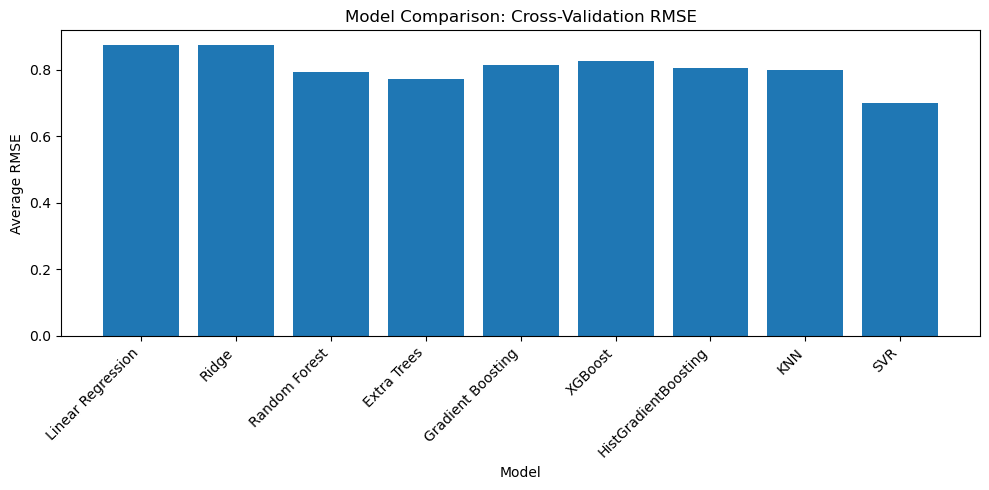

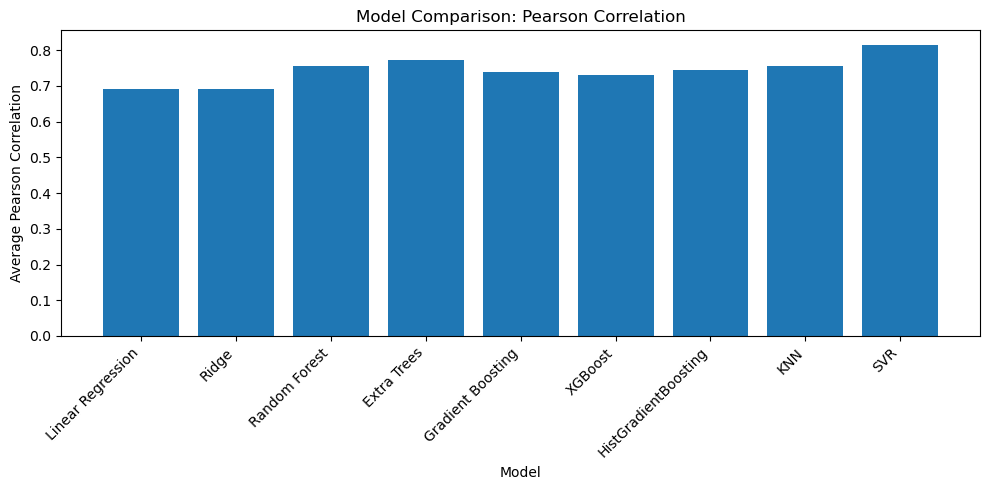

In [43]:
# Comparing models using their cross-validation results
# Replace these values only if the recorded results differ.
model_results = pd.DataFrame({"Model": ["Linear Regression", 
                                        "Ridge", 
                                        "Random Forest", 
                                        "Extra Trees", 
                                        "Gradient Boosting", 
                                        "XGBoost", 
                                        "HistGradientBoosting", 
                                        "KNN", 
                                        "SVR"],
                              "RMSE" : [
                                    0.8739, 0.8739, 0.7938, 0.7702,
                                    0.8147, 0.8245, 0.8040, 0.7972, 0.6995
                                       ],
                              "Pearson Correlation": [
                                    0.6904, 0.6904, 0.7543, 0.7715,
                                    0.7384, 0.7305, 0.7449, 0.7552, 0.8146
                                    ]})

#cross-validation RMSE
plt.figure(figsize=(10, 5))
plt.bar(model_results["Model"], model_results["RMSE"])
plt.title("Model Comparison: Cross-Validation RMSE")
plt.xlabel("Model")
plt.ylabel("Average RMSE")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Pearson correlation
plt.figure(figsize=(10, 5))
plt.bar(model_results["Model"], model_results["Pearson Correlation"])
plt.title("Model Comparison: Pearson Correlation")
plt.xlabel("Model")
plt.ylabel("Average Pearson Correlation")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Actual vs. predicted + residual plots

Out-of-fold RMSE: 0.7006
Out-of-fold Pearson correlation: 0.8247


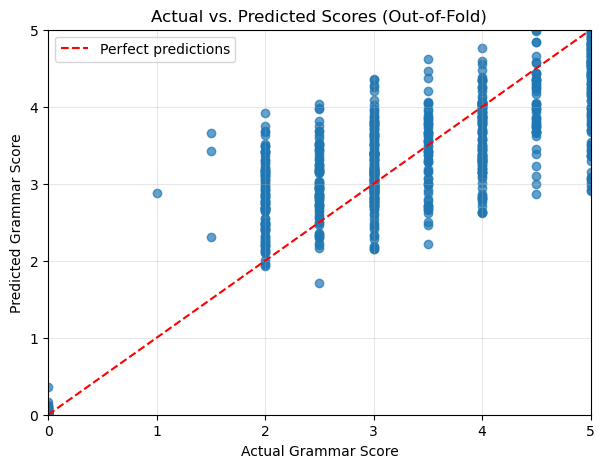

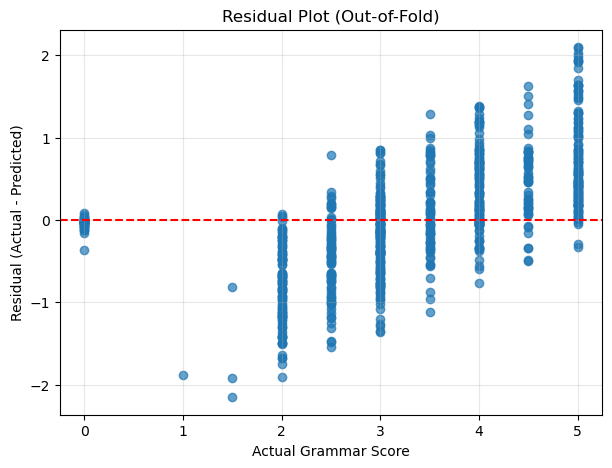

In [44]:

import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr

# out-of-fold predictions on the training dataset
oof_predictions = np.zeros(len(Y_train))

for train_idx, val_idx in kf.split(X_train):
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("svr", SVR(
            kernel="rbf",
            C=10,
            gamma=0.1,
            epsilon=0.1
        ))
    ])

    model.fit(X_train[train_idx], Y_train.iloc[train_idx])
    oof_predictions[val_idx] = model.predict(X_train[val_idx])

actual = np.asarray(Y_train)
residuals = actual - oof_predictions

oof_rmse = np.sqrt(mean_squared_error(actual, oof_predictions))
oof_pearson = pearsonr(actual, oof_predictions)[0]

print(f"Out-of-fold RMSE: {oof_rmse:.4f}")
print(f"Out-of-fold Pearson correlation: {oof_pearson:.4f}")

# Plot 1: Actual vs predicted scores
plt.figure(figsize=(7, 5))
plt.scatter(actual, oof_predictions, alpha=0.7)
plt.plot([0, 5], [0, 5], "r--", label="Perfect predictions")
plt.xlim(0, 5)
plt.ylim(0, 5)
plt.xlabel("Actual Grammar Score")
plt.ylabel("Predicted Grammar Score")
plt.title("Actual vs. Predicted Scores (Out-of-Fold)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Plot 2: Residuals vs actual scores
plt.figure(figsize=(7, 5))
plt.scatter(actual, residuals, alpha=0.7)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Actual Grammar Score")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot (Out-of-Fold)")
plt.grid(alpha=0.3)
plt.show()

### Final Model Evaluation

The selected model is an RBF-kernel Support Vector Regressor (SVR)  with C = 10, gamma = 0.1, and epsilon = 0.1. 
It achieved a mean six-fold cross-validation RMSE of approximately 0.6995 and mean Pearson correlation of 0.8146. 
Across all out-of-fold predictions, the RMSE was 0.7006 and Pearson correlation was 0.8247.

The final model was trained on the full training dataset, achieving a training RMSE of approximately 0.0944. 
The substantial gap between training and validation RMSE suggests potential overfitting.
Actual-vs-predicted and residual plots were used to inspect out-of-fold performance. 
Speaker-grouped validation could not be performed because reliable speaker IDs were unavailable. 
Genuine test performance cannot be calculated from the provided random test labels.


In [46]:
submission = pd.read_csv("Sowmya_Balagala.csv")
submission.to_csv("Sowmya_Balagala.csv", index=False)

print("CSV saved successfully!")

CSV saved successfully!
